           mean       std    min  25% Quartile  50% (Median)  75% Quartile  \
Oil    1.149979  7.803353 -47.52       -2.9050         1.010        4.9800   
Banks  1.244017  6.816028 -36.47       -1.8900         1.315        4.3800   
Txtls  0.978596  8.189742 -36.02       -3.1825         0.955        4.9725   
Toys   0.917862  9.761930 -43.34       -4.2625         0.960        5.5000   
Rtail  1.112196  6.836516 -31.29       -2.3025         1.090        4.4950   

          max   kurtosis  skewness  
Oil     68.84   7.629970  0.640366  
Banks   56.87   6.816107  0.213174  
Txtls   85.94  11.474771  1.218661  
Toys   104.10  15.251647  1.651421  
Rtail   72.09  11.736666  0.951643  


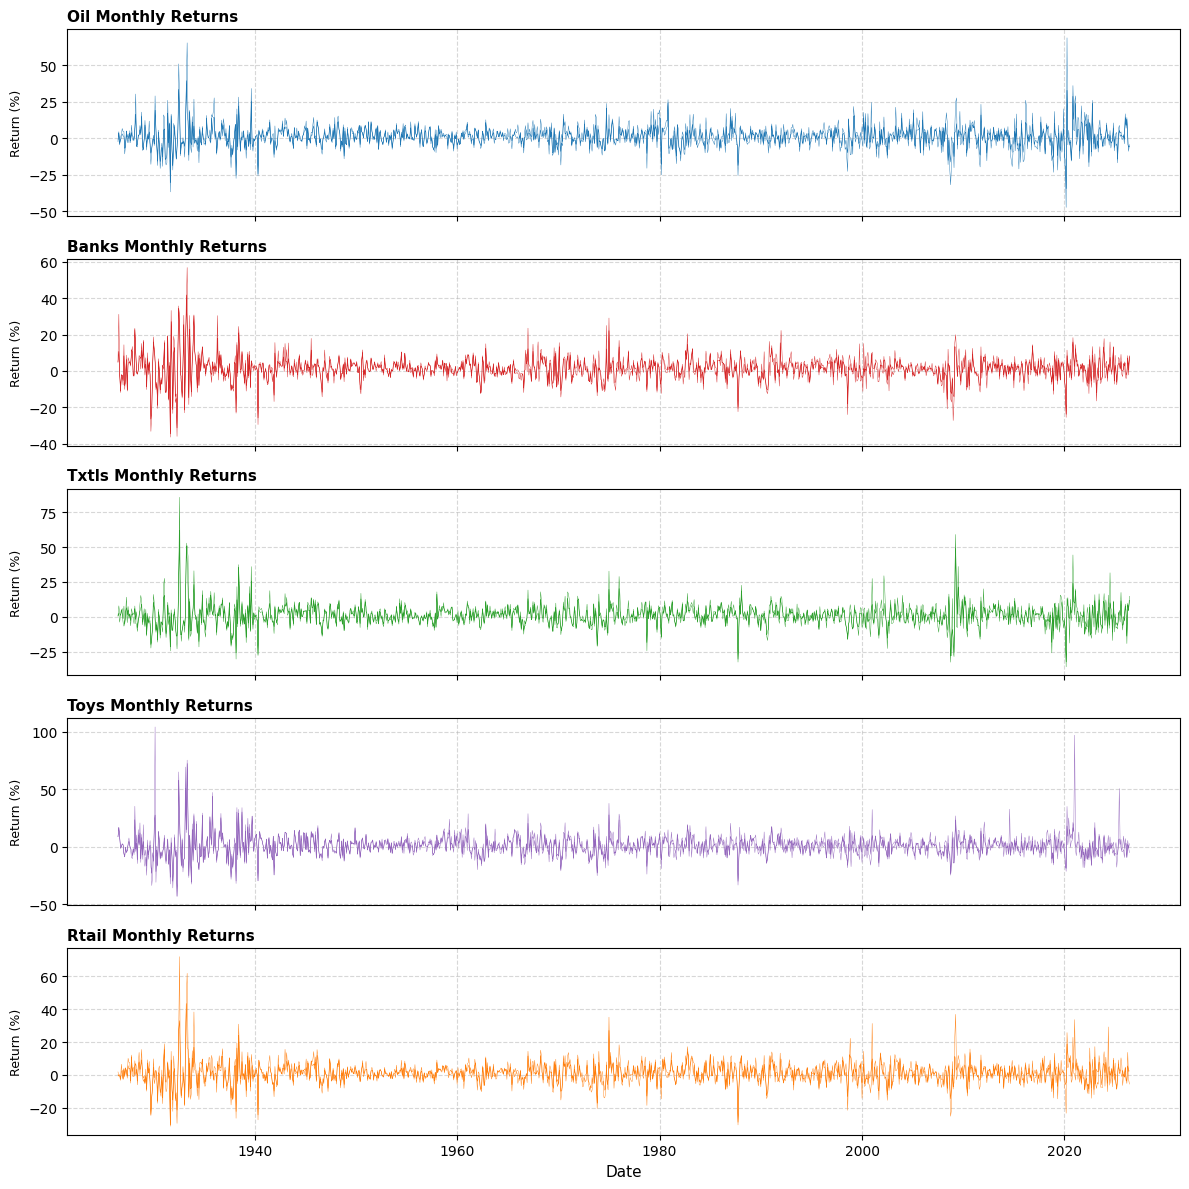

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

# Load the CSV
returns = pd.read_csv('49_Industry_Portfolios.csv', skiprows=11, engine='python', on_bad_lines='skip')
FF5=pd.read_csv('F-F_Research_Data_5_Factors_2x3.csv', skiprows=4, engine='python', on_bad_lines='skip')
momentum=pd.read_csv('F-F_Momentum_Factor.csv', skiprows=13, engine='python', on_bad_lines='skip')

# Rename the first column to 'Date'
returns = returns.rename(columns={returns.columns[0]: 'Date'})
FF5 = FF5.rename(columns={FF5.columns[0]: 'Date'})
momentum = momentum.rename(columns={momentum.columns[0]: 'Date'})

#Cleaning up the column strings to remove white space
returns.columns = returns.columns.str.strip()
FF5.columns = FF5.columns.str.strip()
momentum.columns = momentum.columns.str.strip()

# Choosing which industries to use
keep_cols = ['Date', 'Oil', 'Banks', 'Txtls', 'Toys', 'Rtail']

# Only keep the chosen industry returns
returns = returns[keep_cols]

# Removing the unused rows
returns = returns.iloc[:2402].reset_index(drop=True)
FF5 = FF5.iloc[:756].reset_index(drop=True)
momentum = momentum.iloc[:1195].reset_index(drop=True)

# Change data type to numeric
returns = returns.apply(pd.to_numeric, errors='coerce')
FF5 = FF5.apply(pd.to_numeric, errors='coerce')
momentum = momentum.apply(pd.to_numeric, errors='coerce')

#Join the factors together
factors = pd.merge(FF5, momentum, on='Date')

#
desc_stats = pd.DataFrame(
    {
        'mean': returns.drop(columns=['Date']).mean(),
        'std': returns.drop(columns=['Date']).std(),
        'min': returns.drop(columns=['Date']).min(),
        '25% Quartile': returns.drop(columns=['Date']).quantile(0.25),
        '50% (Median)': returns.drop(columns=['Date']).median(),
        '75% Quartile': returns.drop(columns=['Date']).quantile(0.75),
        'max': returns.drop(columns=['Date']).max(),
        'kurtosis': returns.drop(columns=['Date']).kurtosis(),
        'skewness': returns.drop(columns=['Date']).skew()
    }
)

print(desc_stats)

# Convert date to datetime strings YYYYMM
returns['Date'] = pd.to_datetime(
    returns['Date'].astype(str).str.split('.').str[0], 
    format='%Y%m', 
    errors='coerce'
)


industry_cols = ['Oil', 'Banks', 'Txtls', 'Toys', 'Rtail']

colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e"]
# Create a 5x1 grid of plots sharing the same x-axis
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 12), sharex=True)

for ax, col,color in zip(axes, industry_cols,colors):
    ax.plot(returns['Date'], returns[col], linewidth=0.3, color=color)
    ax.set_title(f'{col} Monthly Returns', fontsize=11, fontweight='bold', loc='left')
    ax.set_ylabel('Return (%)', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Date', fontsize=11)
plt.tight_layout()
plt.show()

            mean       std    min  25% Quartile  50% (Median)  75% Quartile  \
Mkt-RF  0.600820  4.463052 -23.19       -1.9600         1.015        3.4300   
SMB     0.186481  3.023179 -15.54       -1.5800         0.030        1.9425   
HML     0.298413  2.968311 -13.83       -1.4325         0.215        1.7600   
RMW     0.239220  2.253332 -18.95       -0.8725         0.250        1.3100   
CMA     0.245569  2.072117  -7.08       -1.0425         0.090        1.4925   
RF      0.362923  0.260519   0.00        0.1500         0.380        0.4900   
Mom     0.621548  4.179464 -34.36       -0.9825         0.715        2.9100   

          max   kurtosis  skewness  
Mkt-RF  16.10   1.725004 -0.491924  
SMB     18.46   3.059547  0.358410  
HML     12.86   2.177249  0.090716  
RMW     13.05  10.574136 -0.380466  
CMA      9.01   1.340350  0.268441  
RF       1.35   0.832425  0.671474  
Mom     18.05   9.756146 -1.294490  


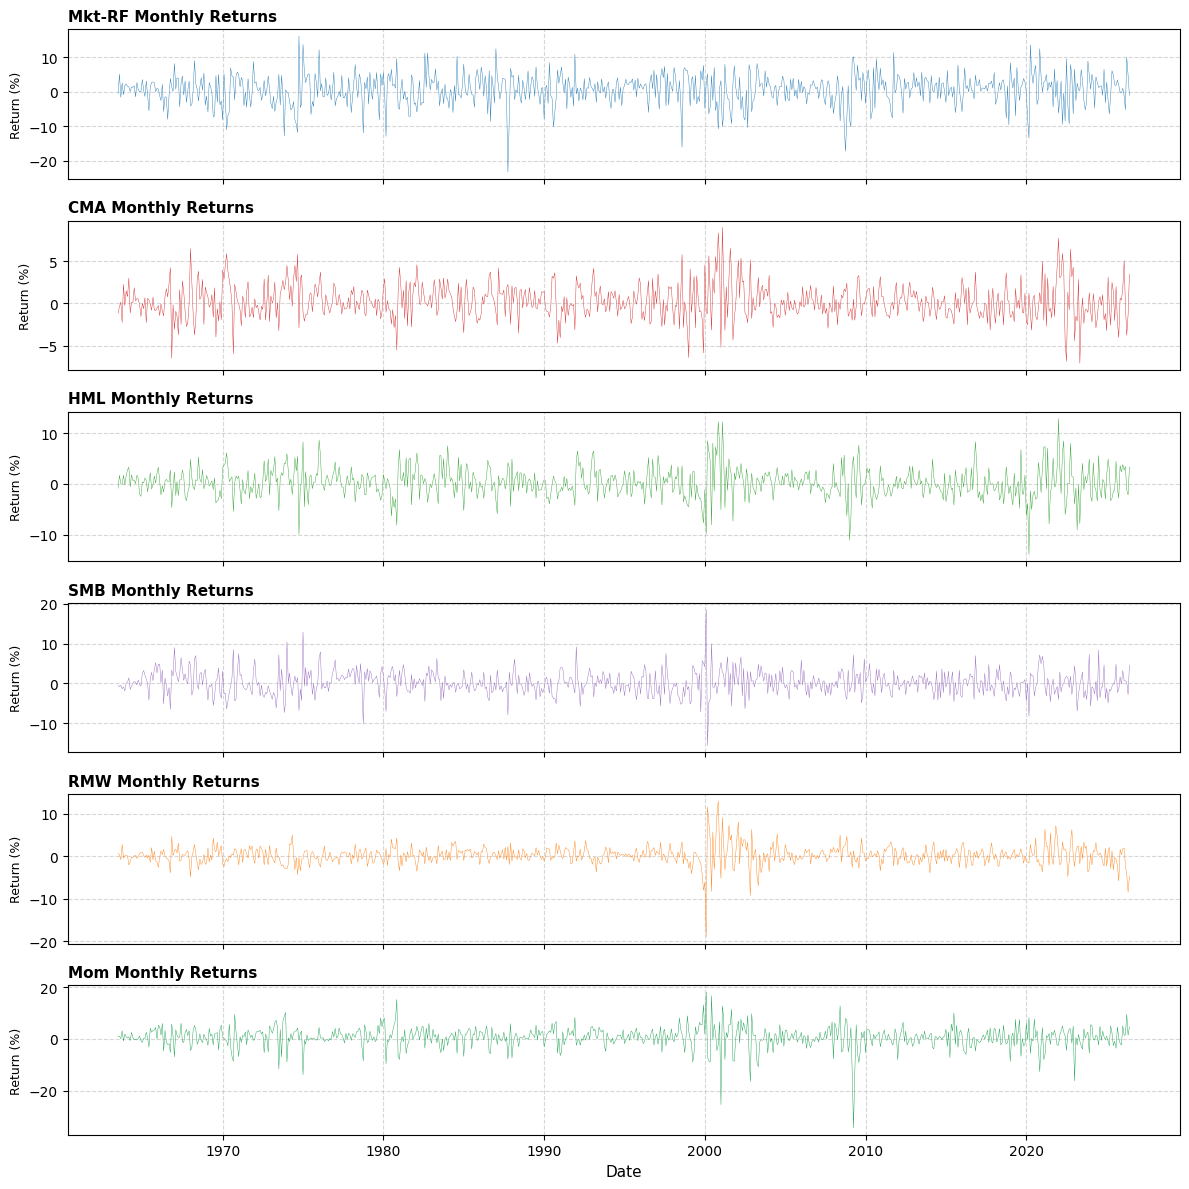

In [33]:
desc_stats_factors = pd.DataFrame(
    {
        'mean': factors.drop(columns=['Date']).mean(),
        'std': factors.drop(columns=['Date']).std(),
        'min': factors.drop(columns=['Date']).min(),
        '25% Quartile': factors.drop(columns=['Date']).quantile(0.25),
        '50% (Median)': factors.drop(columns=['Date']).median(),
        '75% Quartile': factors.drop(columns=['Date']).quantile(0.75),
        'max': factors.drop(columns=['Date']).max(),
        'kurtosis': factors.drop(columns=['Date']).kurtosis(),
        'skewness': factors.drop(columns=['Date']).skew()
    }
)

print(desc_stats_factors)

# Convert date to datetime strings YYYYMM
factors['Date'] = pd.to_datetime(
    factors['Date'].astype(str).str.split('.').str[0], 
    format='%Y%m', 
    errors='coerce'
)

factor_cols = ['Mkt-RF', 'CMA', 'HML', 'SMB', 'RMW','Mom']
colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e","#129e4a"]

fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(12, 12), sharex=True)

for ax, col,color in zip(axes, factor_cols,colors):
    ax.plot(factors['Date'], factors[col], linewidth=0.3, color=color)
    ax.set_title(f'{col} Monthly Returns', fontsize=11, fontweight='bold', loc='left')
    ax.set_ylabel('Return (%)', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)


plt.xlabel('Date', fontsize=11)
plt.tight_layout()
plt.show()

In [34]:
# Question 4a
CAPM = pd.merge(factors, returns, on='Date')

X = CAPM["Mkt-RF"]
X_with_const = sm.add_constant(X)

dependent_vars = {}
for col in ["Oil", "Banks", "Txtls", "Toys", "Rtail"]:
    dependent_vars[f"{col}"] = CAPM[col] - CAPM["RF"]

dependent_vars["Momentum"] = CAPM["Mom"]

results = []

for name, Y in dependent_vars.items():
    model = sm.OLS(Y, X_with_const).fit()

    results.append(
        {
            "Portfolio/Factor": name,
            "Mean excess returns": dependent_vars[name].mean(),
            "Alpha": model.params["const"],
            "Alpha t-stat": model.tvalues["const"],
            "Beta": model.params["Mkt-RF"],
            "Beta t-stat": model.tvalues["Mkt-RF"],
            "R-squared": model.rsquared,
        }
    )

capm_results = pd.DataFrame(results)

print(capm_results.to_string(index=False))


Portfolio/Factor  Mean excess returns     Alpha  Alpha t-stat      Beta  Beta t-stat  R-squared
             Oil             0.725635  0.125236      0.776712  0.999300    27.891895   0.340023
           Banks             0.688366  0.111728      1.146020  0.959753    44.303797   0.565196
           Txtls             0.556296 -0.142507     -0.988613  1.163083    36.311932   0.466159
            Toys             0.455165 -0.263495     -1.697615  1.196132    34.681342   0.443379
           Rtail             0.731257  0.076298      0.776559  1.090107    49.931942   0.622802
        Momentum             0.621548  0.714106      6.675288 -0.154053    -6.480773   0.027062


In [35]:
# Question 4b

X2 = CAPM[["Mkt-RF","SMB","HML","RMW","CMA"]]
X2_with_const = sm.add_constant(X2)

results2 = []

for name, Y in dependent_vars.items():
    model2 = sm.OLS(Y, X2_with_const).fit()

    results2.append(
        {
            "Industry portfolio": name,
            "Intercept": model2.params["const"],
            "Intercept t-stat": model2.tvalues["const"],
            "Beta Mkt-RF": model2.params["Mkt-RF"],
            "Beta Mkt-RF t-stat": model2.tvalues["Mkt-RF"],
            "Beta SMB": model2.params["SMB"],
            "Beta SMB t-stat": model2.tvalues["SMB"],
            "Beta HML": model2.params["HML"],
            "Beta HML t-stat": model2.tvalues["HML"],
            "Beta RMW": model2.params["RMW"],
            "Beta RMW t-stat": model2.tvalues["RMW"],
            "Beta CMA": model2.params["CMA"],
            "Beta CMA t-stat": model2.tvalues["CMA"],
        }
    )

capm_results2 = pd.DataFrame(results2)

print(capm_results2.to_string(index=False))

Industry portfolio  Intercept  Intercept t-stat  Beta Mkt-RF  Beta Mkt-RF t-stat  Beta SMB  Beta SMB t-stat  Beta HML  Beta HML t-stat  Beta RMW  Beta RMW t-stat  Beta CMA  Beta CMA t-stat
               Oil  -0.235093         -1.508597     1.065621           28.266350  0.354714         6.501727  0.480369         6.824566  0.161877         2.240583  0.294263         2.800742
             Banks  -0.132363         -1.615238     0.981983           49.534389  0.255952         8.921644  0.795793        21.499875  0.079252         2.086036 -0.299016        -5.412129
             Txtls  -0.565665         -4.696020     1.113080           38.197168  0.948307        22.487288  0.555679        10.213206  0.436483         7.815939  0.024930         0.306968
              Toys  -0.490059         -3.421971     1.083288           31.268463  0.946013        18.868731 -0.021251        -0.328533  0.311143         4.686316  0.203035         2.102829
             Rtail  -0.092540         -1.007379     1.0

In [ ]:
# Question 4c
momentum_portfolios=pd.read_csv('10_Portfolios_Prior_12_2.csv', skiprows=13, engine='python', on_bad_lines='skip')
